# PARA — which condition matches the ground truth best?

**persona · T=0** vs **persona · T=0.7** vs **blind**, all against the real PARA labels.

The question this notebook answers: *whose score distribution looks most like the annotators' — the persona runs, or the rater-agnostic blind run?*

| condition | directory | what it is |
|---|---|---|
| `persona · T=0` | `data/logs_t_0` | every real annotator role-played, greedy decoding |
| `persona · T=0.7` | `data/logs_t_0.7` | same personas, temperature 0.7 requested |
| `blind` | `data/logs_blind` | one generic, rater-agnostic prompt per image (control) |

**"Matches the ground truth" is split into three senses**, because they disagree:
1. **Pooled distribution** — does the overall spread of scores across all ratings look right?
2. **Per-image distribution** — does each *individual image* draw the same distribution of opinion its real annotators gave it? (the demanding one)
3. **Point accuracy** — is each individual prediction close to that annotator's own label?

In [1]:
import glob
import json
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats

BLUE, AQUA, AMBER = "#2a78d6", "#1baf7a", "#d98a1f"
INK, SECONDARY, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
HUMAN_FILL = "#d9d7cd"
GOOD, CRITICAL = "#0ca30c", "#d03b3b"
SEQ = LinearSegmentedColormap.from_list("seq_blue", ["#f4f6f9", "#9dc0e8", "#2a78d6", "#0f3f7d"])

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.labelcolor": SECONDARY, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "axes.labelsize": 10, "legend.fontsize": 9, "legend.frameon": False,
    "figure.dpi": 110, "lines.linewidth": 2, "font.size": 10,
})
pd.set_option("display.width", 175, "display.max_columns", 60, "display.float_format", lambda v: f"{v:.3f}")

CONDITIONS = {
    "persona · T=0":   ("../data/logs_t_0",   "para_full"),
    "persona · T=0.7": ("../data/logs_t_0.7", "para_full"),
    "blind":           ("../data/logs_blind", "para_blind"),
}
COND_COLOR = {"persona · T=0": BLUE, "persona · T=0.7": AQUA, "blind": AMBER}
PRIMARY = "aestheticScore"

## Load all three runs

In [2]:
def _main_shards(dirp, stem):
    fs = sorted(glob.glob(os.path.join(dirp, f"{stem}.shard*of*.json")))
    return [f for f in fs if ".part-" not in f]


def load_condition(dirp, stem):
    shards = _main_shards(dirp, stem)
    if not shards:
        raise FileNotFoundError(f"no shards for {stem} under {dirp}")
    recs, grids, cfg = [], {}, None
    for mf in shards:
        d = json.load(open(mf))
        cfg = d
        for dim, dm in d["metrics"]["per_dimension"].items():
            grids.setdefault(dim, dm["distribution"]["score_grid"])
        for part in d["result_parts"]:
            for r in json.load(open(os.path.join(dirp, part))):
                recs.append({k: v for k, v in r.items() if k not in ("comment", "raw_response")})
    dims = [x["name"] if isinstance(x, dict) else x for x in cfg["dimensions"]]
    df = pd.DataFrame(recs)
    for dim in dims:
        for pfx in ("gt_", "pred_"):
            df[pfx + dim] = pd.to_numeric(df[pfx + dim], errors="coerce")
    return df, dims, grids, cfg


RAW, CFGS = {}, {}
for lbl, (dirp, stem) in CONDITIONS.items():
    RAW[lbl], DIMS, GRIDS, CFGS[lbl] = load_condition(dirp, stem)
    print(f"{lbl:16s} ratings={len(RAW[lbl]):7,}  images={RAW[lbl]['imageName'].nunique():5,}")

persona · T=0    ratings= 51,749  images=2,000


persona · T=0.7  ratings=103,477  images=4,000


blind            ratings= 51,749  images=2,000


### Pairing the runs

The runs cover different image samples, so a naive comparison would be confounded. `persona · T=0` and `blind` share an identical task set, and both are a strict subset of `persona · T=0.7` — so we restrict to the tasks **all three** ran and verify the labels line up. Everything below is that paired subset.

In [3]:
# The three runs cover different image samples (T=0.7 is 2x larger). To compare them fairly we
# restrict to the (image, annotator) tasks ALL THREE ran -- a fully paired design.
key = lambda d: set(zip(d["imageName"], d["userId"]))
common = sorted(set.intersection(*[key(d) for d in RAW.values()]))
IDX = pd.MultiIndex.from_tuples(common, names=["imageName", "userId"])
print(f"common (image, annotator) tasks run by all three: {len(IDX):,} over {IDX.get_level_values(0).nunique():,} images")

D = {lbl: d.set_index(["imageName", "userId"]).reindex(IDX) for lbl, d in RAW.items()}

# The ground truth must be identical across conditions for the same task -- verify, don't assume.
base = D["persona · T=0"]
for lbl, d in D.items():
    for dim in DIMS:
        a, b = base[f"gt_{dim}"].to_numpy(), d[f"gt_{dim}"].to_numpy()
        assert np.allclose(a, b, equal_nan=True), f"ground truth differs for {lbl} / {dim}"
print("verified: ground-truth labels identical across all three conditions on these tasks")

GT = base[[f"gt_{d}" for d in DIMS]].rename(columns={f"gt_{d}": d for d in DIMS})
IMG = IDX.get_level_values(0).to_numpy()

common (image, annotator) tasks run by all three: 51,749 over 2,000 images
verified: ground-truth labels identical across all three conditions on these tasks


In [4]:
meta = pd.DataFrame({
    lbl: {"temperature": CFGS[lbl].get("temperature"), "top_k": CFGS[lbl].get("top_k"),
          "top_p": CFGS[lbl].get("top_p"), "persona_blind": CFGS[lbl].get("persona_blind"),
          "ratings (all)": len(RAW[lbl]), "ratings (paired)": len(IDX),
          "generated_at": CFGS[lbl].get("generated_at", "")[:19]}
    for lbl in CONDITIONS}).T
meta

,temperature,top_k,top_p,persona_blind,ratings (all),ratings (paired),generated_at
persona · T=0,0.000,None,None,None,51749,51749,2026-07-06T19:38:28
persona · T=0.7,0.700,None,None,False,103477,51749,2026-07-14T13:27:37
blind,0.700,None,None,True,51749,51749,2026-07-08T15:43:44


> **⚠️ The decoding caveat that shapes this whole notebook.** `Qwen2-VL` ships `top_k=1, top_p=0.001` and none of these runs override it, so **decoding was greedy even at T=0.7**. Consequences: (a) `persona · T=0.7` is effectively a second greedy run, not a sampling condition; (b) in `blind` the prompt is identical for every annotator of an image, so all of them receive a **byte-identical answer** — blind's within-image spread is ~0 *by construction*. Any per-image distribution result for blind reflects that artefact, not taste.

In [5]:
# --- valid mask: keep only tasks where ALL THREE conditions parsed an answer, per axis -------
def valid_mask(dim):
    m = GT[dim].notna().to_numpy().copy()
    for lbl in CONDITIONS:
        m &= D[lbl][f"pred_{dim}"].notna().to_numpy()
    return m


def to_idx(vals, grid):
    lo, step = grid[0], grid[1] - grid[0]
    return np.clip(np.rint((np.asarray(vals, float) - lo) / step).astype(int), 0, len(grid) - 1)


def norm_hist(vals, grid):
    h = np.bincount(to_idx(vals, grid), minlength=len(grid)).astype(float)
    return h / h.sum() if h.sum() else h


# --- distribution distances on a uniform grid (EMD via CDF; KS = max CDF gap; TVD) -----------
def dist_metrics(h_lab, h_mod, grid):
    step = grid[1] - grid[0]
    cl, cm = np.cumsum(h_lab), np.cumsum(h_mod)
    return dict(emd=step * np.abs(cl[:-1] - cm[:-1]).sum(),
                ks=np.abs(cl - cm).max(),
                tvd=0.5 * np.abs(h_lab - h_mod).sum())


def per_image_hists(codes, vals, grid, n_img):
    M = np.zeros((n_img, len(grid)))
    np.add.at(M, (codes, to_idx(vals, grid)), 1.0)
    return M


def per_image_dists(h_lab, h_mod, grid):
    # row-wise EMD / KS between each image's label histogram and its model histogram
    step = grid[1] - grid[0]
    pl = h_lab / h_lab.sum(1, keepdims=True)
    pm = h_mod / h_mod.sum(1, keepdims=True)
    cl, cm = pl.cumsum(1), pm.cumsum(1)
    gap = np.abs(cl - cm)
    return step * gap[:, :-1].sum(1), gap.max(1)


def bootstrap_floor(h_lab, grid, B=20, seed=0):
    # how far a resample of the humans lands from the humans -- the irreducible noise floor
    rng = np.random.default_rng(seed)
    step = grid[1] - grid[0]
    n = h_lab.sum(1).astype(int)
    p = h_lab / n[:, None]
    out = np.zeros(len(n))
    for i in range(len(n)):
        draws = rng.multinomial(n[i], p[i], size=B) / n[i]
        cd, cl = draws.cumsum(1), p[i].cumsum()
        out[i] = (step * np.abs(cd[:, :-1] - cl[None, :-1]).sum(1)).mean()
    return out

## Compute the comparison

For each axis: pooled distribution distances, per-image distances against a human bootstrap floor, a location/spread decomposition, and point accuracy — for all three conditions on the identical paired tasks.

In [6]:
# Compute everything once: marginal distances, per-image distances, spread, point accuracy.
marg_rows, img_rows = [], []
PER_IMAGE = {}          # (dim) -> DataFrame of per-image stats, one block per condition
FLOOR = {}

for dim in DIMS:
    grid = np.asarray(GRIDS[dim], float)
    m = valid_mask(dim)
    lab = GT[dim].to_numpy()[m]
    codes, uniq = pd.factorize(IMG[m])
    n_img = len(uniq)
    hl = per_image_hists(codes, lab, grid, n_img)
    FLOOR[dim] = bootstrap_floor(hl, grid)
    lab_mu = pd.Series(lab).groupby(codes).mean().to_numpy()
    lab_sd = pd.Series(lab).groupby(codes).std(ddof=0).to_numpy()
    h_lab_marg = norm_hist(lab, grid)

    blocks = []
    for lbl in CONDITIONS:
        pred = D[lbl][f"pred_{dim}"].to_numpy()[m]
        # marginal (pooled over every rating)
        mm = dist_metrics(h_lab_marg, norm_hist(pred, grid), grid)
        marg_rows.append(dict(axis=dim, condition=lbl, **mm))
        # per-image distribution
        hm = per_image_hists(codes, pred, grid, n_img)
        emd_i, ks_i = per_image_dists(hl, hm, grid)
        mod_mu = pd.Series(pred).groupby(codes).mean().to_numpy()
        mod_sd = pd.Series(pred).groupby(codes).std(ddof=0).to_numpy()
        blocks.append(pd.DataFrame(dict(image=uniq, condition=lbl, emd=emd_i, ks=ks_i,
                                        floor=FLOOR[dim], label_mean=lab_mu, label_sd=lab_sd,
                                        model_mean=mod_mu, model_sd=mod_sd)))
        img_rows.append(dict(
            axis=dim, condition=lbl,
            emd=emd_i.mean(), ks=ks_i.mean(), floor=FLOOR[dim].mean(),
            emd_ratio=emd_i.mean() / FLOOR[dim].mean(),
            loc_err=np.abs(mod_mu - lab_mu).mean(),      # location: |mean model - mean label|
            spread_err=np.abs(mod_sd - lab_sd).mean(),   # spread:   |sd model - sd label|
            model_sd=mod_sd.mean(), label_sd=lab_sd.mean(),
            frac_zero_spread=float((mod_sd == 0).mean()),
            mae=np.abs(pred - lab).mean(), bias=(pred - lab).mean(),
            pearson=stats.pearsonr(pred, lab)[0],
        ))
    PER_IMAGE[dim] = pd.concat(blocks, ignore_index=True)

MARG = pd.DataFrame(marg_rows)
IMGM = pd.DataFrame(img_rows)
print(f"computed over {len(DIMS)} axes x {len(CONDITIONS)} conditions on {len(IDX):,} paired tasks")
print("per-axis images:", PER_IMAGE[PRIMARY]["image"].nunique())

computed over 9 axes x 3 conditions on 51,749 paired tasks
per-axis images: 2000


## 1 · Pooled distribution

All ratings thrown into one histogram per axis. This asks the easy question: does the model produce roughly the right *mix* of scores overall?

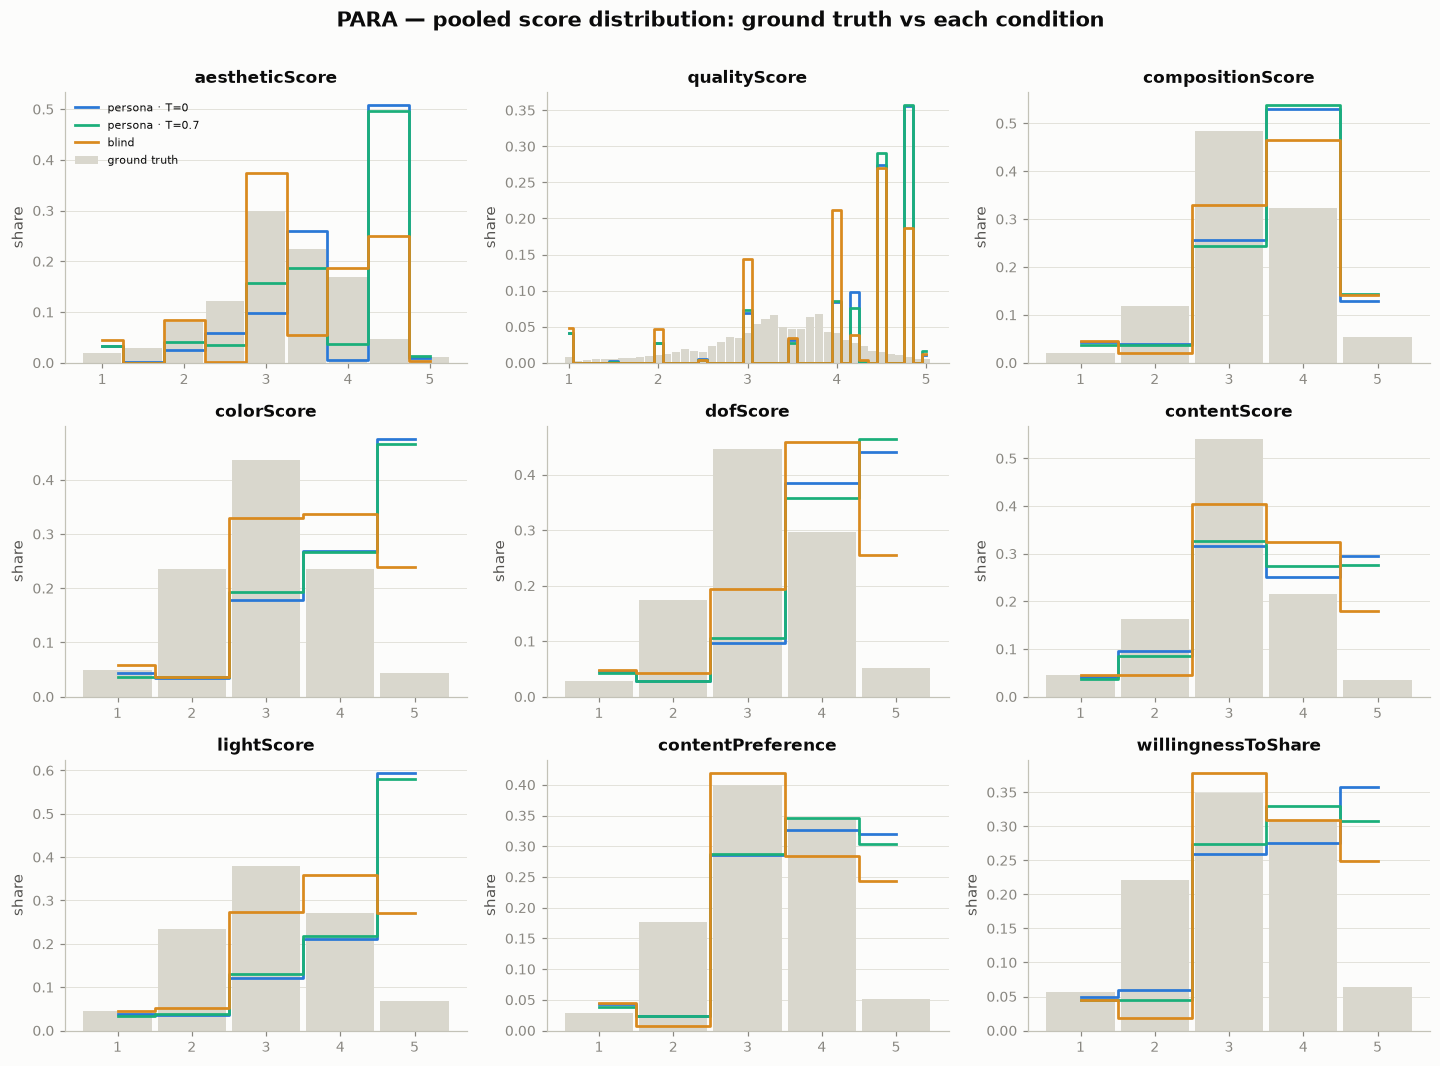

In [7]:
# The POOLED distribution: all ratings on one axis, labels vs each condition.
nr, nc = 3, 3
fig, axes = plt.subplots(nr, nc, figsize=(4.4 * nc, 3.2 * nr), squeeze=False)
for ax, dim in zip(axes.flat, DIMS):
    grid = np.asarray(GRIDS[dim], float)
    m = valid_mask(dim)
    step = grid[1] - grid[0]
    ax.bar(grid, norm_hist(GT[dim].to_numpy()[m], grid), width=step * 0.92,
           color=HUMAN_FILL, label="ground truth", zorder=1)
    for lbl in CONDITIONS:
        ax.step(grid, norm_hist(D[lbl][f"pred_{dim}"].to_numpy()[m], grid), where="mid",
                color=COND_COLOR[lbl], lw=1.8, label=lbl, zorder=3)
    ax.set_title(dim); ax.xaxis.grid(False); ax.set_ylabel("share")
axes.flat[0].legend(loc="upper left", fontsize=7.5)
fig.suptitle("PARA — pooled score distribution: ground truth vs each condition",
             fontsize=14, fontweight="bold", color=INK, y=1.005)
fig.tight_layout(); plt.show()

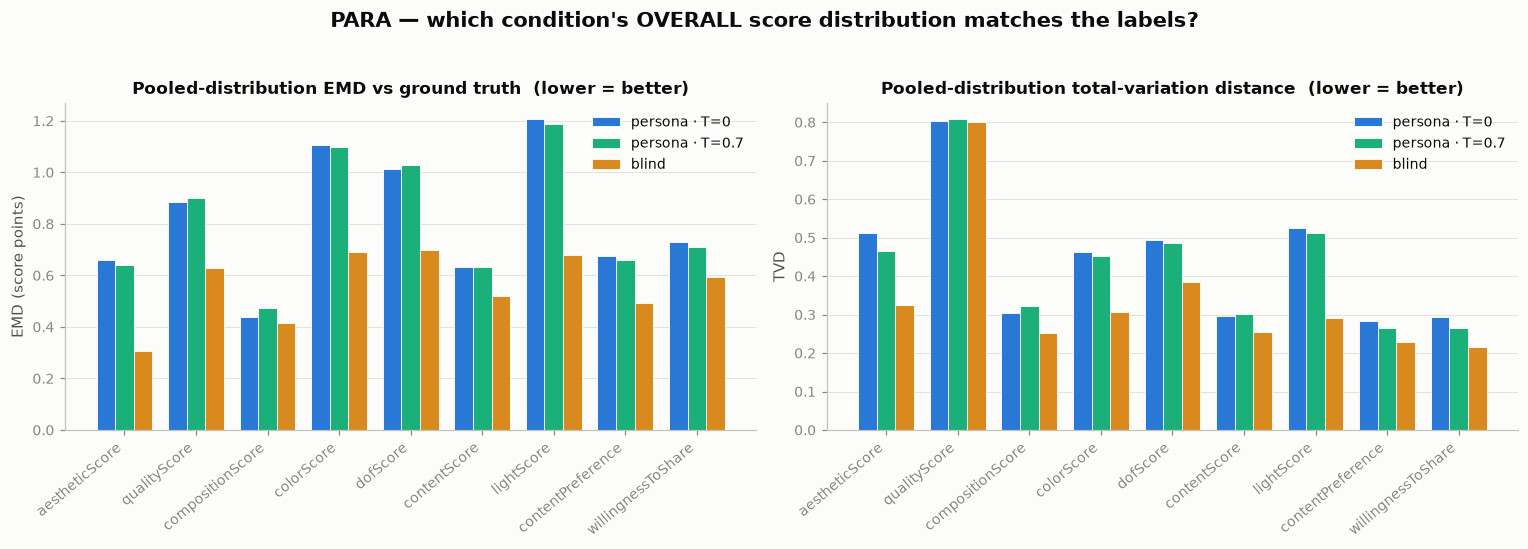

In [8]:
# Ranking on the POOLED distribution: lower EMD = closer to the ground-truth distribution.
x = np.arange(len(DIMS)); w = 0.26
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.8))
for i, lbl in enumerate(CONDITIONS):
    s = MARG[MARG["condition"] == lbl].set_index("axis").reindex(DIMS)
    a1.bar(x + (i - 1) * w, s["emd"], w, color=COND_COLOR[lbl], label=lbl,
           edgecolor=SURFACE, linewidth=0.6)
    a2.bar(x + (i - 1) * w, s["tvd"], w, color=COND_COLOR[lbl], label=lbl,
           edgecolor=SURFACE, linewidth=0.6)
a1.set_title("Pooled-distribution EMD vs ground truth  (lower = better)")
a1.set_ylabel("EMD (score points)")
a2.set_title("Pooled-distribution total-variation distance  (lower = better)")
a2.set_ylabel("TVD")
for ax in (a1, a2):
    ax.set_xticks(x, DIMS, rotation=40, ha="right"); ax.xaxis.grid(False); ax.legend()
fig.suptitle("PARA — which condition's OVERALL score distribution matches the labels?",
             fontsize=14, fontweight="bold", color=INK, y=1.03)
fig.tight_layout(); plt.show()

## 2 · Per-image distribution

The demanding question: for a single image, do the ~25 model scores look like the ~25 real ratings? The red diamonds are the human bootstrap floor — how far a resample of the annotators themselves lands from the annotators. Nothing can honestly beat that floor.

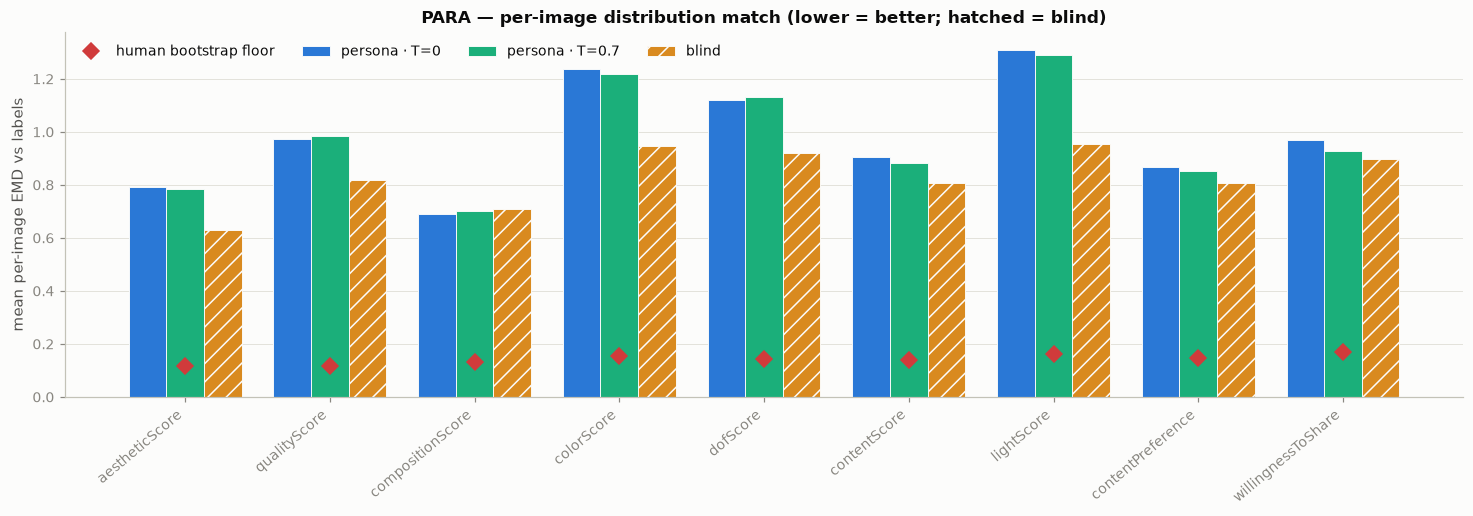

condition,blind,persona · T=0,persona · T=0.7
axis,,,
aestheticScore,0.628,0.794,0.783
qualityScore,0.817,0.972,0.983
compositionScore,0.709,0.692,0.703
colorScore,0.948,1.238,1.217
dofScore,0.919,1.121,1.132
contentScore,0.807,0.907,0.884
lightScore,0.953,1.311,1.290
contentPreference,0.806,0.869,0.853
willingnessToShare,0.899,0.971,0.930


In [9]:
# The harder test: does each IMAGE draw the same spread of opinion as its real annotators?
x = np.arange(len(DIMS)); w = 0.26
fig, ax = plt.subplots(figsize=(13.5, 4.8))
for i, lbl in enumerate(CONDITIONS):
    s = IMGM[IMGM["condition"] == lbl].set_index("axis").reindex(DIMS)
    ax.bar(x + (i - 1) * w, s["emd"], w, color=COND_COLOR[lbl], label=lbl,
           edgecolor=SURFACE, linewidth=0.6, hatch="//" if lbl == "blind" else None)
fl = IMGM[IMGM["condition"] == "blind"].set_index("axis").reindex(DIMS)["floor"]
ax.plot(x, fl, "D", color=CRITICAL, ms=7, label="human bootstrap floor")
ax.set_xticks(x, DIMS, rotation=40, ha="right"); ax.xaxis.grid(False)
ax.set_ylabel("mean per-image EMD vs labels")
ax.set_title("PARA — per-image distribution match (lower = better; hatched = blind)")
ax.legend(ncol=4); fig.tight_layout(); plt.show()
IMGM.pivot(index="axis", columns="condition", values="emd").reindex(DIMS)

### Location vs. spread

EMD conflates two different failures: the distribution can sit in the wrong *place*, or have the wrong *width*. Splitting them is what makes the blind-vs-persona answer honest.

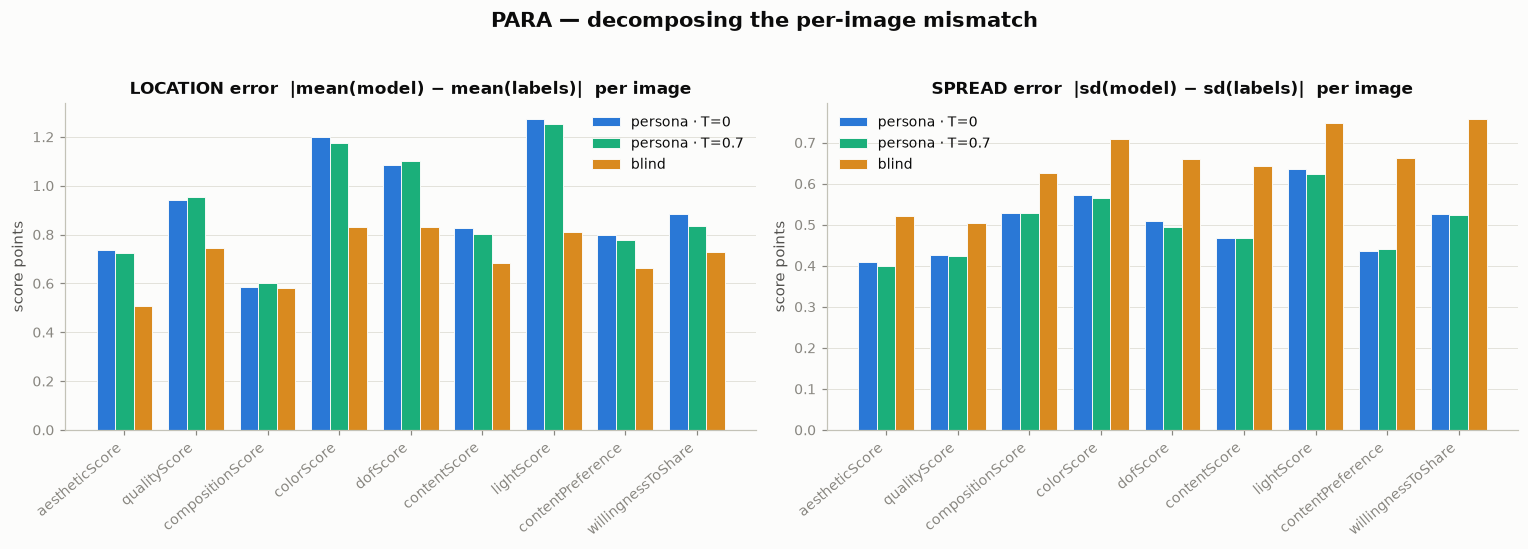

In [10]:
# EMD mixes two errors. Split them: is the image's distribution in the wrong PLACE, or the
# wrong WIDTH? Blind cannot vary within an image at all, so its spread error is structural.
x = np.arange(len(DIMS)); w = 0.26
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.8))
for i, lbl in enumerate(CONDITIONS):
    s = IMGM[IMGM["condition"] == lbl].set_index("axis").reindex(DIMS)
    a1.bar(x + (i - 1) * w, s["loc_err"], w, color=COND_COLOR[lbl], label=lbl,
           edgecolor=SURFACE, linewidth=0.6)
    a2.bar(x + (i - 1) * w, s["spread_err"], w, color=COND_COLOR[lbl], label=lbl,
           edgecolor=SURFACE, linewidth=0.6)
a1.set_title("LOCATION error  |mean(model) − mean(labels)|  per image")
a1.set_ylabel("score points")
a2.set_title("SPREAD error  |sd(model) − sd(labels)|  per image")
a2.set_ylabel("score points")
for ax in (a1, a2):
    ax.set_xticks(x, DIMS, rotation=40, ha="right"); ax.xaxis.grid(False); ax.legend()
fig.suptitle("PARA — decomposing the per-image mismatch", fontsize=14,
             fontweight="bold", color=INK, y=1.03)
fig.tight_layout(); plt.show()

## 3 · Diversity of opinion

How much do the model's raters disagree with each other about one image, versus how much the real annotators disagree? This is where the blind control's structural limit is visible.

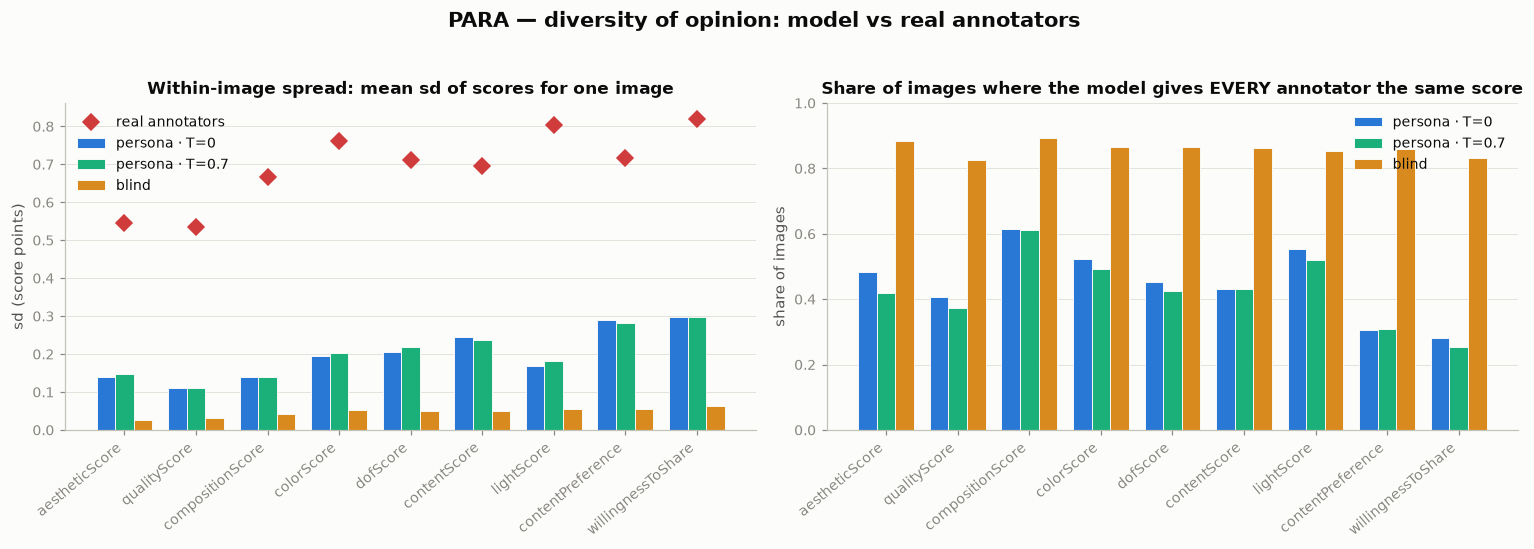

In [11]:
# Do the models reproduce the DIVERSITY of opinion an image draws?
x = np.arange(len(DIMS)); w = 0.26
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.8))
lab_sd = IMGM[IMGM["condition"] == "blind"].set_index("axis").reindex(DIMS)["label_sd"]
for i, lbl in enumerate(CONDITIONS):
    s = IMGM[IMGM["condition"] == lbl].set_index("axis").reindex(DIMS)
    a1.bar(x + (i - 1) * w, s["model_sd"], w, color=COND_COLOR[lbl], label=lbl,
           edgecolor=SURFACE, linewidth=0.6)
    a2.bar(x + (i - 1) * w, s["frac_zero_spread"], w, color=COND_COLOR[lbl], label=lbl,
           edgecolor=SURFACE, linewidth=0.6)
a1.plot(x, lab_sd, "D", color=CRITICAL, ms=7, label="real annotators")
a1.set_title("Within-image spread: mean sd of scores for one image")
a1.set_ylabel("sd (score points)")
a2.set_title("Share of images where the model gives EVERY annotator the same score")
a2.set_ylabel("share of images"); a2.set_ylim(0, 1)
for ax in (a1, a2):
    ax.set_xticks(x, DIMS, rotation=40, ha="right"); ax.xaxis.grid(False); ax.legend()
fig.suptitle("PARA — diversity of opinion: model vs real annotators", fontsize=14,
             fontweight="bold", color=INK, y=1.03)
fig.tight_layout(); plt.show()

## 4 · Point accuracy

The third sense of matching: each prediction against that annotator's own label.

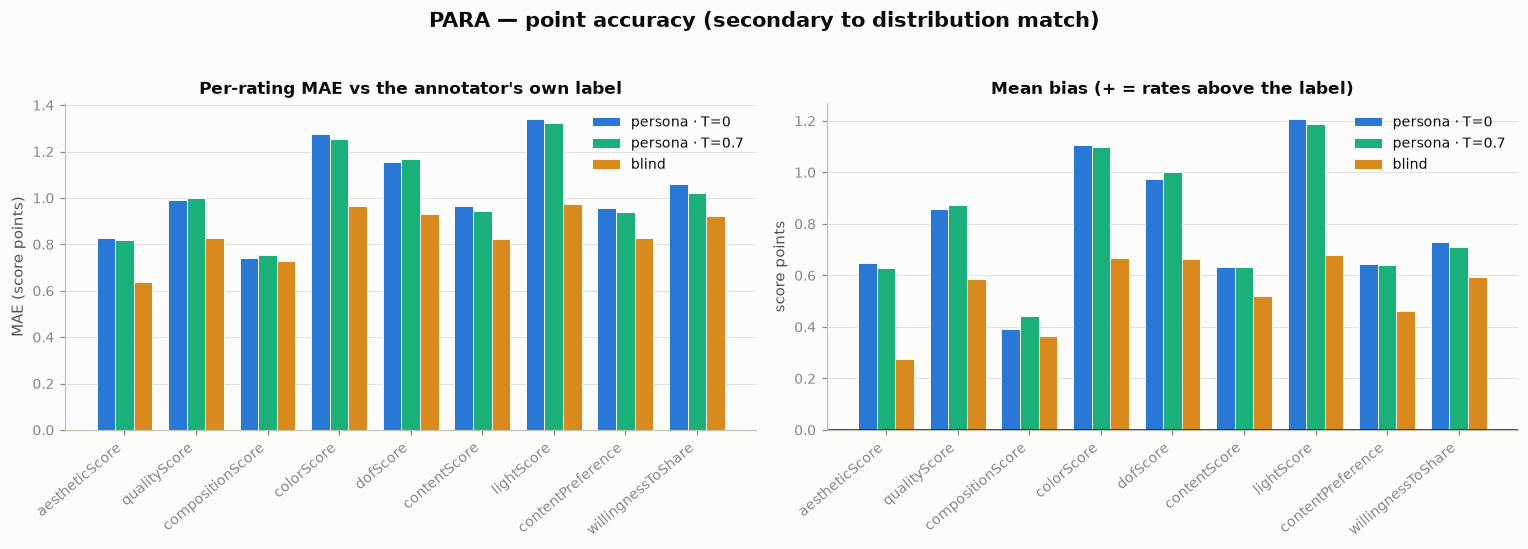

In [12]:
# Secondary sense of "matching": per-rating point accuracy against each annotator's own label.
x = np.arange(len(DIMS)); w = 0.26
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.8))
for i, lbl in enumerate(CONDITIONS):
    s = IMGM[IMGM["condition"] == lbl].set_index("axis").reindex(DIMS)
    a1.bar(x + (i - 1) * w, s["mae"], w, color=COND_COLOR[lbl], label=lbl,
           edgecolor=SURFACE, linewidth=0.6)
    a2.bar(x + (i - 1) * w, s["bias"], w, color=COND_COLOR[lbl], label=lbl,
           edgecolor=SURFACE, linewidth=0.6)
a1.set_title("Per-rating MAE vs the annotator's own label"); a1.set_ylabel("MAE (score points)")
a2.set_title("Mean bias (+ = rates above the label)"); a2.set_ylabel("score points")
a2.axhline(0, color=INK, lw=1)
for ax in (a1, a2):
    ax.set_xticks(x, DIMS, rotation=40, ha="right"); ax.xaxis.grid(False); ax.legend()
fig.suptitle("PARA — point accuracy (secondary to distribution match)", fontsize=14,
             fontweight="bold", color=INK, y=1.03)
fig.tight_layout(); plt.show()

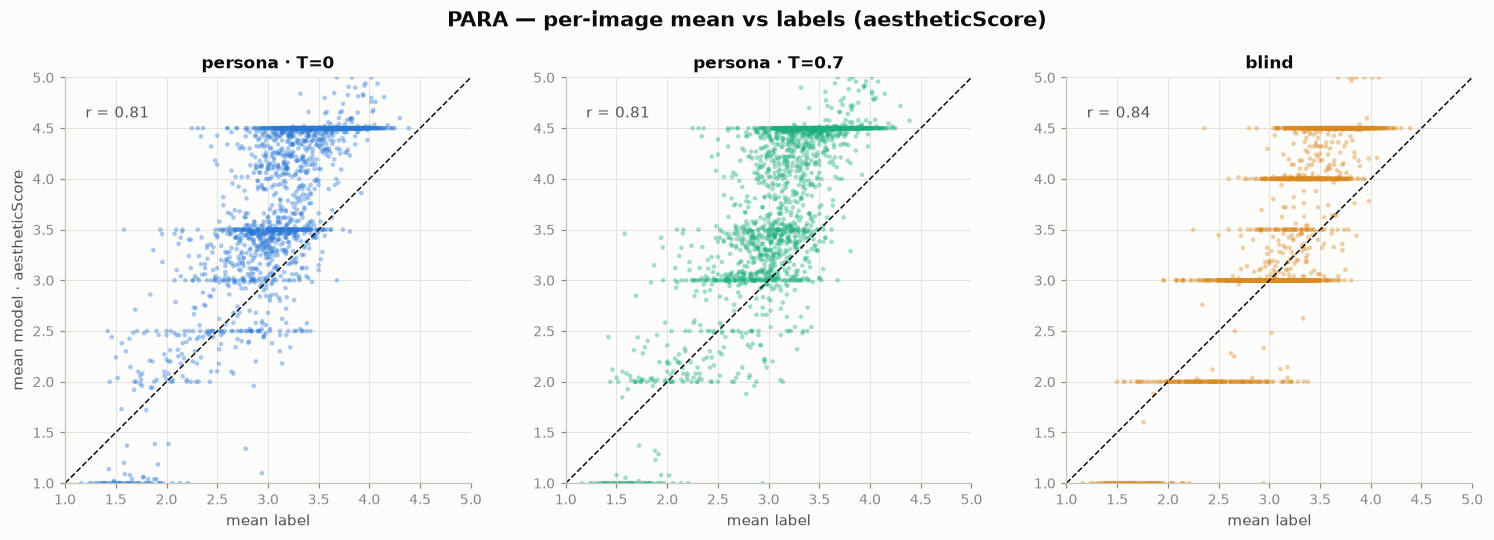

In [13]:
# Per-image mean, model vs labels, on the headline axis -- the banding shows each
# condition's quantisation; blind's tight stripes are the greedy-decoding collapse.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
grid = GRIDS[PRIMARY]; lo, hi = grid[0], grid[-1]
for ax, lbl in zip(axes, CONDITIONS):
    s = PER_IMAGE[PRIMARY]
    s = s[s["condition"] == lbl]
    ax.scatter(s["label_mean"], s["model_mean"], s=9, color=COND_COLOR[lbl], alpha=0.4,
               edgecolor="none")
    ax.plot([lo, hi], [lo, hi], color=INK, lw=1, ls="--")
    r = stats.pearsonr(s["model_mean"], s["label_mean"])[0]
    ax.annotate(f"r = {r:.2f}", xy=(0.05, 0.93), xycoords="axes fraction", va="top",
                fontsize=10, color=SECONDARY)
    ax.set_title(lbl); ax.set_xlabel("mean label"); ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_aspect("equal", "box")
axes[0].set_ylabel(f"mean model · {PRIMARY}")
fig.suptitle(f"PARA — per-image mean vs labels ({PRIMARY})", fontsize=14,
             fontweight="bold", color=INK, y=1.02)
fig.tight_layout(); plt.show()

## Verdict — blind or persona?

In [14]:
# Who wins? Count axes won per criterion (lower is better on all four).
crit = {"pooled distribution (EMD)": ("marg", "emd"),
        "per-image distribution (EMD)": ("img", "emd"),
        "per-image spread error": ("img", "spread_err"),
        "per-rating MAE": ("img", "mae")}
tally = {}
for name, (src, col) in crit.items():
    t = (MARG if src == "marg" else IMGM).pivot(index="axis", columns="condition", values=col)
    tally[name] = t.reindex(DIMS).idxmin(axis=1).value_counts()
wins = pd.DataFrame(tally).T.fillna(0).astype(int)
wins = wins.reindex(columns=[c for c in CONDITIONS if c in wins.columns])
print("===== PARA: axes won per criterion (out of 9; lower metric = better) =====")
print(wins.to_string())

print("\n===== mean over the 9 axes =====")
summ = pd.DataFrame({
    "pooled EMD": MARG.groupby("condition")["emd"].mean(),
    "pooled TVD": MARG.groupby("condition")["tvd"].mean(),
    "per-image EMD": IMGM.groupby("condition")["emd"].mean(),
    "per-image EMD / human floor": IMGM.groupby("condition")["emd_ratio"].mean(),
    "location err": IMGM.groupby("condition")["loc_err"].mean(),
    "spread err": IMGM.groupby("condition")["spread_err"].mean(),
    "model within-image sd": IMGM.groupby("condition")["model_sd"].mean(),
    "images w/ zero spread": IMGM.groupby("condition")["frac_zero_spread"].mean(),
    "MAE": IMGM.groupby("condition")["mae"].mean(),
    "bias": IMGM.groupby("condition")["bias"].mean(),
}).reindex(list(CONDITIONS))
print(summ.round(3).to_string())
print(f"\nreal annotators' mean within-image sd: {IMGM['label_sd'].mean():.3f}"
      f"   |   human bootstrap floor (EMD): {IMGM['floor'].mean():.3f}")

best_pool = summ["pooled EMD"].idxmin()
best_img = summ["per-image EMD"].idxmin()
best_spread = summ["spread err"].idxmin()
print("\n----- answer -----")
print(f"closest POOLED distribution      : {best_pool}")
print(f"closest PER-IMAGE distribution   : {best_img}")
print(f"closest per-image SPREAD         : {best_spread}")

===== PARA: axes won per criterion (out of 9; lower metric = better) =====
                              persona · T=0  persona · T=0.7  blind
pooled distribution (EMD)                 0                0      9
per-image distribution (EMD)              1                0      8
per-image spread error                    3                6      0
per-rating MAE                            0                0      9

===== mean over the 9 axes =====
                 pooled EMD  pooled TVD  per-image EMD  per-image EMD / human floor  location err  spread err  model within-image sd  images w/ zero spread   MAE  bias
condition                                                                                                                                                              
persona · T=0         0.816       0.442          0.986                        6.929         0.926       0.501                  0.199                  0.450 1.036 0.799
persona · T=0.7       0.815       0.431        

### How to read the verdict
- A win on **pooled distribution** is cheap: a model can produce the right overall mix of scores while assigning them to the wrong images and the wrong people.
- A win on **per-image distribution** is the meaningful one — but read it together with the location/spread split. Blind's per-image spread is ~0 *by construction* (greedy decoding + an identical prompt for every annotator), so if blind wins on per-image EMD it is winning on **location** (being less biased), while structurally failing to reproduce disagreement at all.
- The persona runs are the only ones that can express within-image disagreement, since the prompt differs per annotator — the question is whether that variation is *real* signal or just noise, which the spread-error panel answers.
- Everything here is on the 51,749 tasks all three ran; `persona · T=0.7` has ~2x more data overall, unused here so the comparison stays paired.